# Exercises

## Exercise 1: Image characteristics
---

**A.** Distiguishing pixels   

Fluctuations in the activitation of the neuron can be directly observed on the video or in a temporal trace plot of each pixel. Plotting the temporal trace will allow us to see the calcium transient dinamic, if a pixel belonging to a neuron is selected. 

* Select a set of *N* random pixels from the ROI and plot the temporal evolution of pixel value. If the random pixels are choosen from an active neuron, you will be able to see the calcium transcient dynamic. Try this a few time to appreciate the results.

**B.** Temporal statistics of pixel activation
 * For the selected pixels, plot the histogram of pixel value. What are the difference in different regions?, and how can that help to distinguish a pixel that belongs to aneuron from a background pixel?

* If we can already see the calcium traces from individual pixels, why do we need to run source extraction to segment the neurons? Why, as a starter, would not be a good idea to work directly with the temporal traces of the pixels? 

In [2]:
import os

os.chdir("C:/Users/larsb/Cognitive_neuroscience_RU/neuro-analysis-nongit/neural-data-master/02-calcium_imaging")

import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import psutil
from pathlib import Path
import os

# CaImAn funtions and objects
import caiman as cm
from caiman.motion_correction import MotionCorrect, high_pass_filter_space
from caiman.source_extraction.cnmf import params as params
from caiman.source_extraction import cnmf
from caiman.source_extraction.cnmf.cnmf import load_CNMF

import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import auxiliary_functions as aux


import seaborn as sns
sns.set_theme(context='notebook',style='white',font_scale=1.5)






In [ ]:
download_data('https://surfdrive.surf.nl/files/index.php/s/yQT6yv34jDu6csE')

In [3]:
input_tif_file_path_FOV = 'data/calcium_video.tif'   
input_tif_file_path = 'data/caiman_video_trial_0.tif'  

In [4]:
FOV = cm.load(input_tif_file_path_FOV)
ROI = cm.load(input_tif_file_path)


(500, 300, 400)


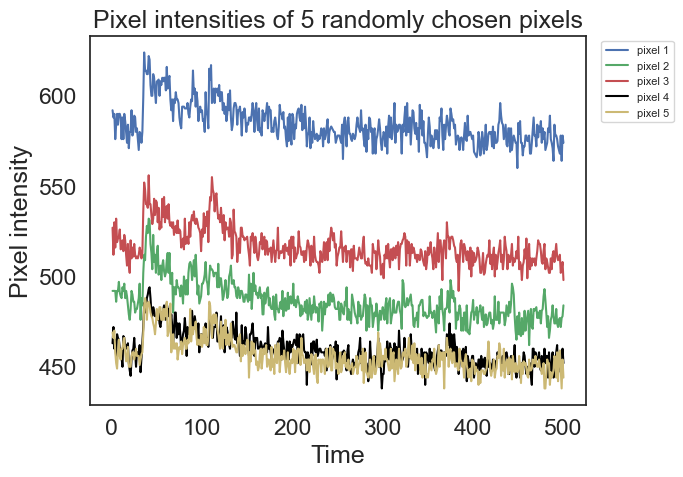

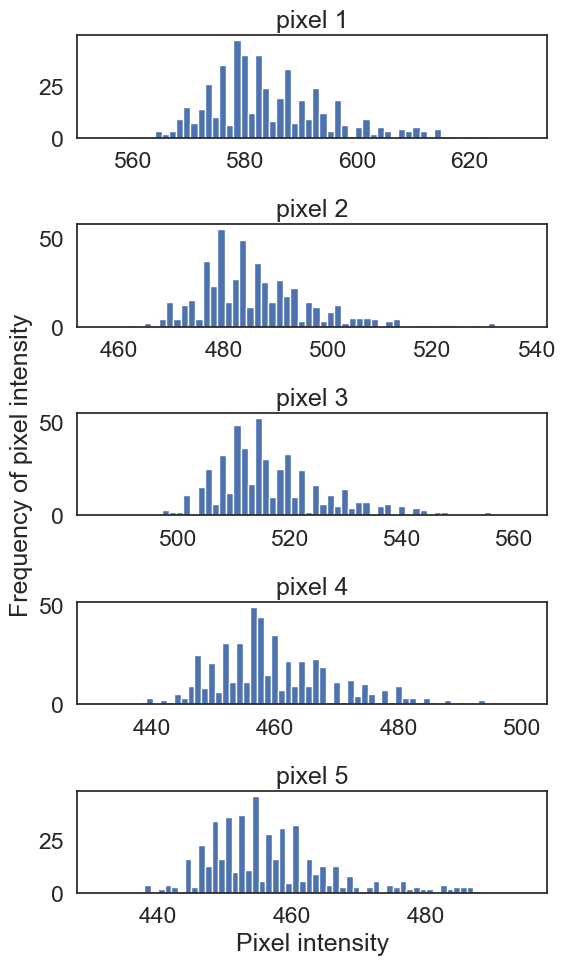

In [5]:
import random

print(ROI.shape)


colors = ["b", "g", "r", "black", "y" ]
pixels = []

fig1, axs1 = plt.subplots()

fig2, axs2 = plt.subplots(5, 1, figsize=(6, 10))

pixel_names = ["pixel 1", "pixel 2", "pixel 3", "pixel 4", "pixel 5"]

for i in range(5):
    rand_x = random.randint(1,ROI.shape[2])
    rand_y = random.randint(1,ROI.shape[1])
    pixels.append(ROI[:,rand_y, rand_x])
    axs1.plot(np.arange(1,ROI.shape[0]+1, 1), pixels[i], color = colors[i])
    axs2[i].hist(ROI[:,rand_y, rand_x], bins = 50)
    axs2[i].set_xlim(ROI[:,rand_y, rand_x].min() - 10, ROI[:,rand_y, rand_x].max() + 10)
    axs2[i].set_title(pixel_names[i]) 

axs1.set_xlabel("Time")
axs1.set_ylabel("Pixel intensity")
axs1.set_title("Pixel intensities of 5 randomly chosen pixels")
axs1.legend(pixel_names,
            loc = "upper left",
            fontsize = 8,
            bbox_to_anchor=(1.02, 1))
axs2[2].set_ylabel("Frequency of pixel intensity")
axs2[4].set_xlabel("Pixel intensity")


plt.tight_layout()



# Pixels from different regions differ in their pixel intensity values and
# And their distribution differs pixels that might be from an active area,
# and might show a calcium trace show a skewed tail to the right, because of the high
# pixels values duruing a calcium trace (e.g. pixel 1), while background pixels have a more narrow
# distribution around the baseline value which is mainly by noise (e.g. pixel 2)


# Because the pixels are noisy, so you don't know whether the temporal activity
# you see that looks like it comes from within a neuron is noise or activty from
# a neuron and a neuron contains multiple pixels. With source extraction you really
# look at neurons that are correlated in time and space and is therefore more reliable. 
# and the tissue you look at is in a gel and may move over time, so the pixel intensities
# may change just because of movement



## Exercise 2: motion correction parameters
---

One parameter that impacts motion correction performance is the size of the spatial filter that is applyed to the video.

* Use the following function from CaImAn and plot the result of different space filtering applyed to a single frame of the video:from caiman.motion_correction import high_pass_filter_space

* How will this filtering affect the measure of crispness?

* Acording to Pnevmatikakis et al, which other factors are relevant for pw-rigid motion correction?

- Explore the impact of different parameters in the output of motion correction algorithm by measuring crispness in the correlation image of the final outcome. Particularly measure the effect of different spatial filter size by applying motion correction algorithm multiple times and computing the crispness of the output video. 

- Display all crispness values for rigid and not rigid motion correction and plot them agains gSig_filters values.

- If possible, show the impact of the crispness value that comes from changing other relevant paraments.

*Note1: The is no need to save all the motion corrected movies, just save the cripsness values.*

*Note2: gSig_filters is an optional range of posible values, but if your computer gets to slow in the computation reduce the range.*


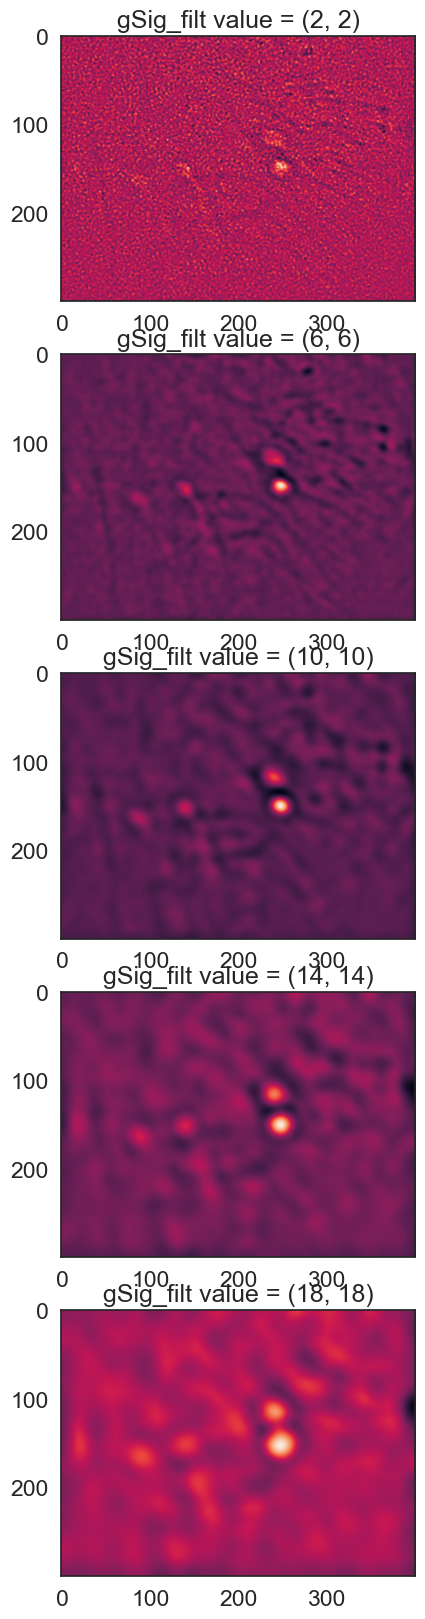

In [6]:
from caiman.motion_correction import high_pass_filter_space

# Defining a single frame that will be used for the filtering
frame = ROI[100, : , :]

# Defining the different filter values used
filt_vals = [(2,2), (6,6), (10,10), (14,14), (18,18)]

# filtering all pixels of the 100th time interval frame with the different filter
# values of filt_vals
fig,axs = plt.subplots(len(filt_vals), 1, figsize = (10,20))
for i in range(len(filt_vals)):
    fil_frame = high_pass_filter_space(frame, gSig_filt=filt_vals[i])
    axs[i].imshow(fil_frame)
    axs[i].set_title(f"gSig_filt value = {filt_vals[i]}")

# With higher values for gSig_filt, more low frequencies are suppressed
# and the higher frequencies remain. As crispness measures the delta I 
# (spatial intensity gradients, change in intensities over space)
# Crispness with increases with high pass filtering

# Relevant factors for pw-rigid motion correction include patch size and overlap,
# template quality and update frequency, interpolation method when applying shifts,
# and constraints on the maximum allowed shift.

In [ ]:
# performing the rigid and the piece wise rigid motion correction
# for different values of the highpass filter in the list gsig_vals
# next for both types of motion correction calculate the crispness of the
# correlation image for all high pass filter values used

parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'gSig_filt': (5, 5),     # size of high pass spatial filtering, used in 1p data
                                'max_shifts': (25, 25),  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                'niter_rig': 1 ,
                                'strides': (48, 48),     # create a new patch every x pixels for pw-rigid correction
                                'overlaps': (96, 96),    # overlap between pathes (size of patch strides+overlaps)
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                'max_deviation_rigid': 15, # maximum deviation allowed for patch with respect to rigid shifts
                                'shifts_opencv': True, 
                                'use_cuda': False, 
                                'nonneg_movie': True,
                                'border_nan': 'copy'}

original_movie = cm.load(input_tif_file_path)
parameters_motion_correction['min_mov'] = np.min(original_movie) 

n_processes = psutil.cpu_count() # counts local cpus
cm.cluster.stop_server() #stop any already running clusters
# Start a new cluster
c, dview, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                 n_processes=n_processes,
                                                 single_thread=False)

gsig_vals = [(2,2), (5,5), (8,8), (12,12), (16,16)]

crispness_rigid = []
crispness_pw = []

for gsig in gsig_vals:
    
    parameters_motion_correction['gSig_filt'] = gsig

    opts = params.CNMFParams(params_dict=parameters_motion_correction)

    mc = MotionCorrect(input_tif_file_path, dview=dview, **opts.get_group('motion'))

    mc.motion_correct_rigid(save_movie=True, template=None)

    total_template_rig = mc.total_template_rig

    mc.motion_correct_pwrigid(save_movie=True, template=total_template_rig)

    final_size = mc.total_template_els.shape

    tmpl_rig, correlations_rig, flows_rig, norms_rig, crisp_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0],
        final_size[0],
        final_size[1],
        False,
        winsize=100,
        play_flow=False,
        resize_fact_flow=0.1
    )


    tmpl_pw, correlations_pw, flows_pw, norms_pw, crisp_pw = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0],
        final_size[0],
        final_size[1],
        False,
        winsize=100,
        play_flow=False,
        resize_fact_flow=0.1
    )

    crispness_rigid.append(crisp_rig)
    crispness_pw.append(crisp_pw)

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


(2, 2) 1058.8414 1057.7177


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


(5, 5) 858.6662 882.8818


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


(8, 8) 821.0469 869.46356


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


(12, 12) 831.9691 889.81476


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.


(16, 16) 893.4375 913.5886


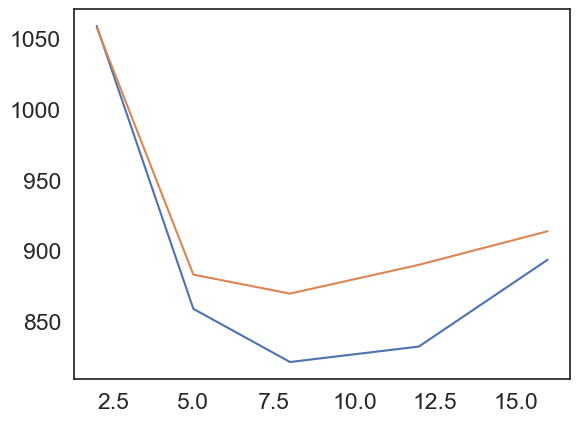

In [ ]:
#plotting the crispness values against the values used in the highpass filter
filt_vals = [g[0] for g in gsig_vals]

plt.plot(filt_vals, crispness_rigid)

plt.plot(filt_vals, crispness_pw)

# first the crispness becomes lower because the noise is filtered out, then it increases
# again because structures are distorted and artefacts can increase which could lead
# to the increase in crispess seen again

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParam

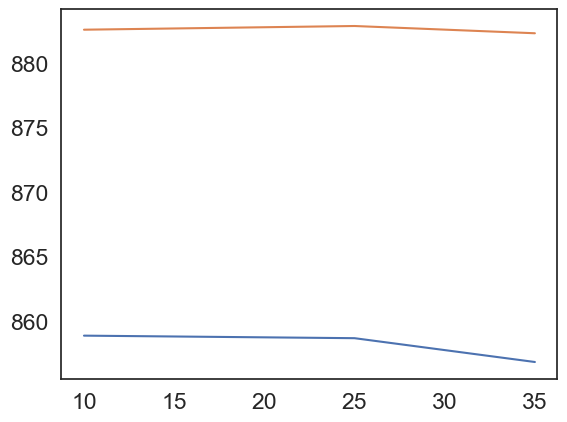

In [24]:
# doing the same as for gSig_filt, but for max_shifts

parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'gSig_filt': (5, 5),     # size of high pass spatial filtering, used in 1p data
                                'max_shifts': (25, 25),  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                'niter_rig': 1 ,
                                'strides': (48, 48),     # create a new patch every x pixels for pw-rigid correction
                                'overlaps': (96, 96),    # overlap between pathes (size of patch strides+overlaps)
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                'max_deviation_rigid': 15, # maximum deviation allowed for patch with respect to rigid shifts
                                'shifts_opencv': True, 
                                'use_cuda': False, 
                                'nonneg_movie': True,
                                'border_nan': 'copy'}

original_movie = cm.load(input_tif_file_path)
parameters_motion_correction['min_mov'] = np.min(original_movie) 

n_processes = psutil.cpu_count() # counts local cpus
cm.cluster.stop_server() #stop any already running clusters
# Start a new cluster
c, dview, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                 n_processes=n_processes,
                                                 single_thread=False)

shift_vals = [(10,10), (25,25), (35,35)]

crispness_rigid = []
crispness_pw = []

for shift in shift_vals:
    
    parameters_motion_correction['max_shifts'] = shift

    opts = params.CNMFParams(params_dict=parameters_motion_correction)

    mc = MotionCorrect(input_tif_file_path, dview=dview, **opts.get_group('motion'))

    mc.motion_correct_rigid(save_movie=True, template=None)

    total_template_rig = mc.total_template_rig

    mc.motion_correct_pwrigid(save_movie=True, template=total_template_rig)

    final_size = mc.total_template_els.shape

    tmpl_rig, correlations_rig, flows_rig, norms_rig, crisp_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0],
        final_size[0],
        final_size[1],
        False,
        winsize=100,
        play_flow=False,
        resize_fact_flow=0.1
    )


    tmpl_pw, correlations_pw, flows_pw, norms_pw, crisp_pw = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0],
        final_size[0],
        final_size[1],
        False,
        winsize=100,
        play_flow=False,
        resize_fact_flow=0.1
    )

    crispness_rigid.append(crisp_rig)
    crispness_pw.append(crisp_pw)


shift_values = [s[0] for s in shift_vals]

plt.plot(shift_values, crispness_rigid)

plt.plot(shift_values, crispness_pw)

In [ ]:
parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'gSig_filt': (5, 5),     # size of high pass spatial filtering, used in 1p data
                                'max_shifts': (25, 25),  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                'niter_rig': 1 ,
                                'strides': (48, 48),     # create a new patch every x pixels for pw-rigid correction
                                'overlaps': (96, 96),    # overlap between pathes (size of patch strides+overlaps)
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                'max_deviation_rigid': 15, # maximum deviation allowed for patch with respect to rigid shifts
                                'shifts_opencv': True, 
                                'use_cuda': False, 
                                'nonneg_movie': True,
                                'border_nan': 'copy'}

original_movie = cm.load(input_tif_file_path)
parameters_motion_correction['min_mov'] = np.min(original_movie) 

n_processes = psutil.cpu_count() # counts local cpus
cm.cluster.stop_server() #stop any already running clusters
# Start a new cluster
c, dview, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                 n_processes=n_processes,
                                                 single_thread=False)

overlap_vals = [(20,20), (60,60), (100,100), (140,140)]

crispness_rigid = []
crispness_pw = []

for overlap in overlap_vals:
    
    parameters_motion_correction['overlaps'] = overlap

    opts = params.CNMFParams(params_dict=parameters_motion_correction)

    mc = MotionCorrect(input_tif_file_path, dview=dview, **opts.get_group('motion'))

    mc.motion_correct_rigid(save_movie=True, template=None)

    total_template_rig = mc.total_template_rig

    mc.motion_correct_pwrigid(save_movie=True, template=total_template_rig)

    final_size = mc.total_template_els.shape

    tmpl_rig, correlations_rig, flows_rig, norms_rig, crisp_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0],
        final_size[0],
        final_size[1],
        False,
        winsize=100,
        play_flow=False,
        resize_fact_flow=0.1
    )


    tmpl_pw, correlations_pw, flows_pw, norms_pw, crisp_pw = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0],
        final_size[0],
        final_size[1],
        False,
        winsize=100,
        play_flow=False,
        resize_fact_flow=0.1
    )

    crispness_rigid.append(crisp_rig)
    crispness_pw.append(crisp_pw)


overlap_values = [o[0] for o in overlap_vals]

plt.plot(overlap_values, crispness_rigid)

plt.plot(overlap_values, crispness_pw)

## Exercise 3: Source extraction parameters 
---

* For a fixed minimum correlation value (ie 0.6) select a range of possible PNR minimun values and study the impact of those in the final source extraction output.

* For a fixed value of PNR (ie 6) select a range of minimum correlation valur and study the impact of those in the final source extraction output.

* How do these paramenters affect the spatial sparcity of the output? Which set of parameter selection procedes the higher number of neurons? Is maximal number of neurons always better? Why?  

* Generate a plot of number of neurons vs PNR (or min corr value) to show how these parameters affect the source extracted signals.

* Are the temporal traces affected by these parameters?

* For different PNR and minimum correlation value plot the correlation image and the selected cells.